In [6]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE_HALF,
    GRID_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    plum,
    sage,
)
from analysis import from_round_one, cpu_seconds_per_round_per_node


def mean_memory_per_node(df):
    per_node_means = []

    for node, df_node in df.groupby("node"):
        memory_values = pd.to_numeric(df_node[df_node.field == "memory_mb"].value)
        per_node_means.append(float(memory_values.mean()))

    return per_node_means


def steady_state_df(csv_path):
    return from_round_one(load_file(csv_path)), read_config_from_csv(csv_path)

In [7]:
metrics_path = "../metrics"
FIG_DIR = "../figures/evaluation/envelope"
os.makedirs(FIG_DIR, exist_ok=True)

In [8]:
K_DIR = os.path.join(metrics_path, "b1_k_sweep")


def steady_rtt_median(path):
    df, _cfg = steady_state_df(path)

    # The round counter marks when the run was actually live.
    round_marker = df[df.field == "current_round"].copy()
    round_marker["v"] = pd.to_numeric(round_marker.value)

    window_start = round_marker["timestamp"].min()
    window_end = round_marker["timestamp"].max() - pd.Timedelta(seconds=5)

    # Keep only RTT samples inside that steady-state window.
    in_window = (df.field == "avg_rtt") & (df.timestamp >= window_start) & (df.timestamp <= window_end)
    rtt = df[in_window].copy()
    rtt["v"] = pd.to_numeric(rtt.value)

    closed = rtt[rtt["v"] > 0]["v"]
    return float(closed.median())


rows = []
for name, path in list_runs(K_DIR):
    config = read_config_from_csv(path)
    K = int(config["max_hops"])
    n_rounds = int(config["n_rounds"])

    rtt = steady_rtt_median(path)

    df = from_round_one(load_file(path))
    cpu_seconds = cpu_seconds_per_round_per_node(df, n_rounds)
    memories = mean_memory_per_node(df)

    rows.append(
        {
            "K": K,
            "run": name,
            "rtt_s": rtt,
            "cpu_s": float(np.mean(cpu_seconds)),
            "mem_mb": float(np.mean(memories)),
        }
    )

df_runs = pd.DataFrame(rows).sort_values(["K", "run"]).reset_index(drop=True)
df_K = df_runs.groupby("K", as_index=False).agg(
    rtt_s=("rtt_s", "mean"),
    cpu_s=("cpu_s", "mean"),
    mem_mb=("mem_mb", "mean"),
)

BITS_PER_STEP = float(np.log2(100))
step_rows = []

for i in range(len(df_K) - 1):
    step_from = df_K.iloc[i]
    step_to = df_K.iloc[i + 1]

    step_rows.append(
        {
            "step": f"{int(step_from.K)}->{int(step_to.K)}",
            "K_dst": int(step_to.K),
            "d_rtt_s": step_to.rtt_s - step_from.rtt_s,
            "d_cpu_s": step_to.cpu_s - step_from.cpu_s,
            "bits_per_rtt_s": BITS_PER_STEP / (step_to.rtt_s - step_from.rtt_s),
            "bits_per_cpu_s": BITS_PER_STEP / (step_to.cpu_s - step_from.cpu_s),
        }
    )
df_steps = pd.DataFrame(step_rows)

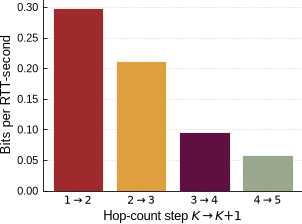

In [9]:
K_COLOR = {1: slate_teal, 2: deep_red, 3: warm_orange, 4: plum, 5: sage}
bar_colors = [K_COLOR[k] for k in df_steps["K_dst"]]
tick_labels = [rf"${int(k) - 1}{{\to}}{int(k)}$" for k in df_steps["K_dst"]]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.bar(df_steps["step"], df_steps["bits_per_rtt_s"], color=bar_colors, edgecolor="white", linewidth=0.6)
ax.set_xticks(range(len(df_steps)))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Hop-count step $K\\rightarrow K{+}1$")
ax.set_ylabel("Bits per RTT-second")
ax.grid(axis="y", **GRID_STYLE)
ax.margins(x=0.04)
save_figure(fig, f"{FIG_DIR}/bits_per_rtt_vs_k.pdf")
plt.show()

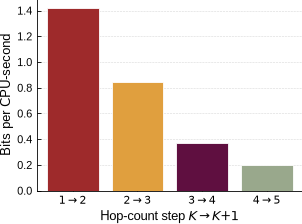

In [10]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.bar(df_steps["step"], df_steps["bits_per_cpu_s"], color=bar_colors, edgecolor="white", linewidth=0.6)
ax.set_xticks(range(len(df_steps)))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Hop-count step $K\\rightarrow K{+}1$")
ax.set_ylabel("Bits per CPU-second")
ax.grid(axis="y", **GRID_STYLE)
ax.margins(x=0.04)
save_figure(fig, f"{FIG_DIR}/bits_per_cpu_vs_k.pdf")
plt.show()